In [1]:
import numpy as np
import pandas as pd

# Set the random seed for reproducibility
np.random.seed(119)

# Create a dataframe of UPI transactions
n_transactions = 1000
genuine_ratio = 0.9
n_genuine = int(n_transactions * genuine_ratio)
n_fraud = n_transactions - n_genuine

In [2]:
n_genuine,n_fraud

(900, 100)

In [3]:
# Create a dataframe with imbalanced dataset

# loc   = the center of the bell curve, i.e. the average value generated
# scale = the standard deviation, how far values spread out from that center
# size  = how many numbers to generate
# Genuine transactions: moderate amounts, spaced out in time
genuine = pd.DataFrame({
    'amount': np.random.normal(loc=500, scale=200, size=n_genuine),
    'gap_minutes': np.random.normal(loc=120, scale=40, size=n_genuine),
    'is_fraud': [0] * n_genuine
})

genuine

,amount,gap_minutes,is_fraud
0,498.497759,117.560664,0
1,740.938553,108.386489,0
2,630.087826,119.720222,0
3,347.387546,168.215102,0
4,392.126343,121.488318,0
...,...,...,...
895,644.330998,182.435320,0
896,527.219433,86.987892,0
897,270.325307,92.802181,0
898,553.262833,79.576053,0


In [4]:
# Fraud transactions: larger amounts, fired one after another
fraud = pd.DataFrame({
    'amount': np.random.normal(loc=1500, scale=400, size=n_fraud),
    'gap_minutes': np.random.normal(loc=15, scale=8, size=n_fraud),
    'is_fraud': [1] * n_fraud
})

fraud

,amount,gap_minutes,is_fraud
0,1576.962048,19.913918,1
1,1214.185252,21.794388,1
2,1643.382210,17.415840,1
3,1879.535287,19.085564,1
4,923.092197,14.829790,1
...,...,...,...
95,2101.604129,18.343321,1
96,964.535245,-4.644932,1
97,1657.276218,24.479541,1
98,1517.233814,21.493862,1


In [8]:
# Stack them into one dataset
df = pd.concat([genuine, fraud]).reset_index(drop=True)
df

,amount,gap_minutes,is_fraud
0,498.497759,117.560664,0
1,740.938553,108.386489,0
2,630.087826,119.720222,0
3,347.387546,168.215102,0
4,392.126343,121.488318,0
...,...,...,...
995,2101.604129,18.343321,1
996,964.535245,-4.644932,1
997,1657.276218,24.479541,1
998,1517.233814,21.493862,1


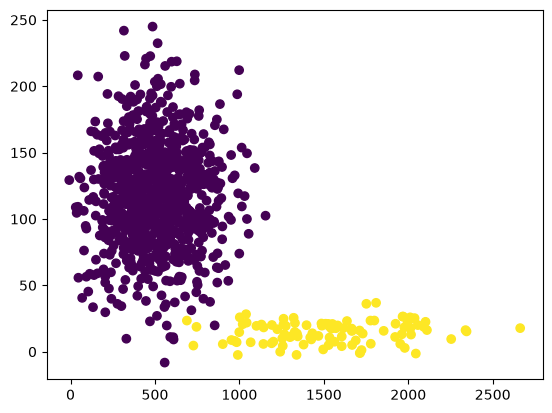

In [27]:
df['is_fraud'].value_counts()
import matplotlib.pyplot as plt
plt.scatter(df['amount'],df['gap_minutes'],c=df['is_fraud'])

In [9]:
df_minority = df[df['is_fraud'] == 1]
df_majority = df[df['is_fraud'] == 0]

In [10]:
from sklearn.utils import resample

# Upscaling
df_minority_upsampled=resample(df_minority,replace=True,n_samples=len(df_majority),random_state=92)

In [13]:
df_minority_upsampled.shape

(900, 3)

In [14]:
df_upscaled=pd.concat([df_majority,df_minority_upsampled])

In [15]:
df_upscaled

,amount,gap_minutes,is_fraud
0,498.497759,117.560664,0
1,740.938553,108.386489,0
2,630.087826,119.720222,0
3,347.387546,168.215102,0
4,392.126343,121.488318,0
...,...,...,...
915,1460.917450,22.895316,1
996,964.535245,-4.644932,1
917,1797.519106,17.933289,1
942,1614.020087,13.892957,1


In [16]:
df_upscaled.is_fraud.value_counts()

is_fraud
0    900
1    900
Name: count, dtype: int64

In [17]:
# Create a dataframe with imbalanced dataset

# loc   = the center of the bell curve, i.e. the average value generated
# scale = the standard deviation, how far values spread out from that center
# size  = how many numbers to generate
# Genuine transactions: moderate amounts, spaced out in time
genuine = pd.DataFrame({
    'amount': np.random.normal(loc=500, scale=200, size=n_genuine),
    'gap_minutes': np.random.normal(loc=120, scale=40, size=n_genuine),
    'is_fraud': [0] * n_genuine
})
fraud = pd.DataFrame({
    'amount': np.random.normal(loc=1500, scale=400, size=n_fraud),
    'gap_minutes': np.random.normal(loc=15, scale=8, size=n_fraud),
    'is_fraud': [1] * n_fraud
})
df = pd.concat([genuine, fraud]).reset_index(drop=True)

In [18]:
df_minority = df[df['is_fraud'] == 1]
df_majority = df[df['is_fraud'] == 0]

In [19]:
# Downscaling
df_majority_downsampled=resample(df_majority,replace=False,n_samples=len(df_minority),random_state=92)

In [20]:
df_majority_downsampled.shape

(100, 3)

In [21]:
df_downscaled=pd.concat([df_minority,df_majority_downsampled])


In [23]:
df_downscaled.shape
df_downscaled.is_fraud.value_counts()

is_fraud
1    100
0    100
Name: count, dtype: int64

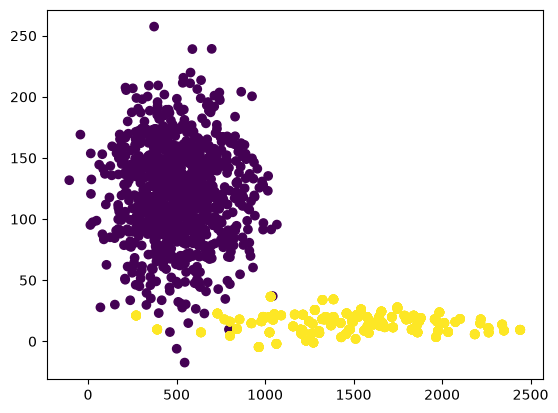

In [26]:
df_upscaled
import matplotlib.pyplot as plt
plt.scatter(df_upscaled['amount'],df_upscaled['gap_minutes'],c=df_upscaled['is_fraud'])